In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
import numpy as np

In [10]:
train_dir  = "AI_banknotes"
img_width,img_height=320,160

In [11]:
train_datagen=ImageDataGenerator(
    rescale=1.0/225,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [12]:
train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 112 images belonging to 9 classes.


In [5]:
money=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(img_width,img_height,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(9,activation='softmax')
])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
money.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
money.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 318, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 159, 79, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 157, 77, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 78, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 76, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 38, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87552)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,206,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,308,873 (43.14 MB)

 Trainable params: 11,308,873 (43.14 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
epochs=200
history=money.fit(train_generator,epochs=epochs)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 555ms/step - accuracy: 0.7679 - loss: 0.6254
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 0.7589 - loss: 0.6433
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 0.8304 - loss: 0.5085
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step - accuracy: 0.8125 - loss: 0.5303
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - accuracy: 0.8393 - loss: 0.5936
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 583ms/step - accuracy: 0.7679 - loss: 0.6268
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.7679 - loss: 0.6970
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 553ms/step - accuracy: 0.7768 - loss: 0.6654
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 540ms/step - accuracy: 0.7411 - loss: 0.6778
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 0.7946 - loss: 0.5566
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.8393 - loss: 0.4544
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 512ms/step - accuracy:

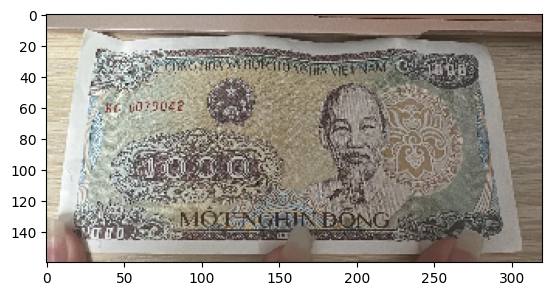

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Kết quả tiên đoán: Tờ 1000


In [18]:
from keras.utils import load_img
import numpy as np
path="/Users/nguyenngockimtuyet/AI_HW/e5f7e875-dd3f-40ee-b1c0-461bc97b8489.jpeg"
img = load_img(path, target_size=(160, 320))
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 160, 320, 3)
prediction=np.argmax(money.predict(img))
#Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
banknotes = class_labels[prediction]
print(f"Kết quả tiên đoán: {banknotes}")


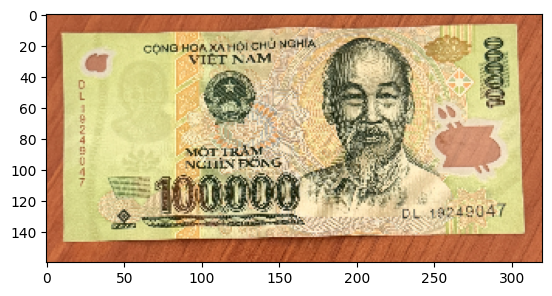

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Kết quả tiên đoán: Tờ 100000


In [17]:
path="703976971_1536292381166764_3113422839076269724_n.jpg"
img = load_img(path, target_size=(160, 320))
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 160, 320, 3)
prediction=np.argmax(money.predict(img))
#Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
banknotes = class_labels[prediction]
print(f"Kết quả tiên đoán: {banknotes}")

In [19]:
money.save("money.h5")

In [3]:
from keras.models import load_model
money1 = load_model("money.h5")

In [4]:
import cv2

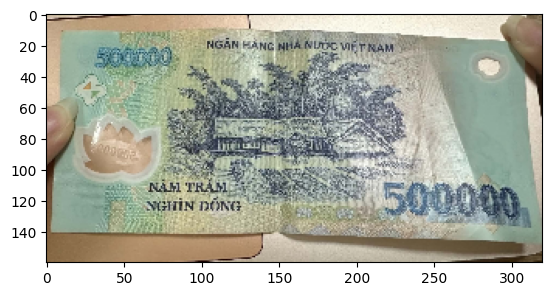

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Người tiên đoán: Tờ 500000
Độ tự tin: 99.05%


In [16]:
img = cv2.imread("/Users/nguyenngockimtuyet/AI_HW/tien500matsau.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (320, 160))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 160, 320, 3)
pred = money1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

In [14]:
print(money1.input_shape)

(None, 320, 160, 3)
